## Implémentation du solveur de Helmholtz 2D en configuration bipériodique, avec CLs de Dirichlet

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr

import matplotlib.colors as colors

#module "maison"
import Chebyshev

In [3]:
Chebyshev.Cheb_mat(8).shape

(8, 8)

On résout 
$$
\left(\partial_y^2+\partial_x^2-\alpha^2\right)\psi(x, y) = RHS(x, y)
$$
sur $x, y \in [-1, 1]$, avec $\psi(x, y=\pm 1) = \pm \cosh(l)\cos(kx)$. La solution est $\psi(x, y) = \cos(kx)\cosh(ly)$ pour $\alpha^2 = k^2-l^2$ et $RHS = \left(l^2 -k^2 - \alpha^2\right)\cos{kx}\cosh{ly}$
Ici, $\alpha^2 = 3$, $k=2$, $l=1$, ce qui donne $RHS = -6\cos{kx}\cosh{ly}$


Au début, on prends $\psi(x, y) = \cosh(y)$, $\psi(x, \pm 1) = \pm \cosh(1)$, $\alpha = 2$, $RHS(x, y) = -\cosh(y)$

In [4]:
def Solve_Helmholtz(Nx,
                    Ny,
                    alpha2 = 0.0,
                    rhs=0.0,
                    CL_y_inf = 0.0,
                    CL_y_sup = 0.0,
                    interval_x = (0.0, 2.0*np.pi),
                    interval_y = (-1.0, 1.0) ): 
    #génération de la grille
    x = np.linspace(interval_x[0], interval_x[1], Nx, endpoint = False)
    y = Chebyshev.collocation_points(Ny, a = interval_y[0], b = interval_y[1])
    
    kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (interval_x[-1] - interval_x[0])/Nx)

    if np.isscalar(rhs) : 
        rhs = rhs *np.ones((Nx, Ny))
    if isinstance(rhs, np.ndarray) and (rhs.shape[0] != Nx or rhs.shape[1] != Ny) : 
        raise ValueError(f"rhs must be of size Nx x Ny (rhs.shape = {rhs.shape})")
    
    psi_num = np.zeros((Nx, Ny))
    psi_num_hat = np.zeros((Nx, Ny), dtype = 'complex')
    rhs_hat = scipy.fft.fft(rhs, axis = 0)
    
    
    D = Chebyshev.Cheb_mat(Ny, a = interval_y[0], b = interval_y[1])
    D2 = D@D
    
    if np.isscalar(CL_y_inf) : 
        BC_y_inf = np.ones(Nx) * CL_y_inf
    elif ( isinstance(CL_y_inf, np.ndarray) == True ) and ( CL_y_inf.shape[0] == Nx and len(CL_y_inf.shape) == 1 ): 
        BC_y_inf = CL_y_inf.copy()
    else : 
        raise ValueError(f"CL_y_inf must be scalar or 1D array of size Nx (CL_y_inf = {CL_y_inf}")

    if np.isscalar(CL_y_sup) : 
        BC_y_sup = np.ones(Nx) * CL_y_sup
    elif ( isinstance(CL_y_sup, np.ndarray) == True ) and ( CL_y_sup.shape[0] == Nx and len(CL_y_sup.shape) == 1 ): 
        BC_y_sup = CL_y_sup.copy()
    else : 
        raise ValueError(f"CL_y_sup must be scalar or 1D array of size Nx (CL_y_sup = {CL_y_sup}")

    BC_y_inf_hat = scipy.fft.fft(BC_y_inf)
    BC_y_sup_hat = scipy.fft.fft(BC_y_sup)

    alpha2_id = alpha2 * np.eye(Ny)
    
    for i in range(0, Nx):
        kx_i = kx[i]
        rhs_hat_i = rhs_hat[i, :].copy()
        diag_add = alpha2_id+kx_i**2
        F = -( alpha2_id + kx_i**2 )
        F[0, 0] = 1.0
        F[-1, -1] = 1.0
        F[1:-1, :] += D2[1:-1, :]

        inv_F = np.linalg.inv(F)
        
        
        BC_hat_inf_i = BC_y_inf_hat[i].copy()
        BC_hat_sup_i = BC_y_sup_hat[i].copy()

        rhs_hat_i[0] = BC_hat_sup_i
        rhs_hat_i[-1] = BC_hat_inf_i

        psi_hat_i = inv_F @ rhs_hat_i
        psi_num_hat[i, :] = psi_hat_i
    
    psi_num = scipy.fft.ifft(psi_num_hat, axis = 0).real
    
    return psi_num
    

Nx = 128
Ny = 128
X.shape (128, 128)
Y.shape (128, 128)
alpha^2 2.0


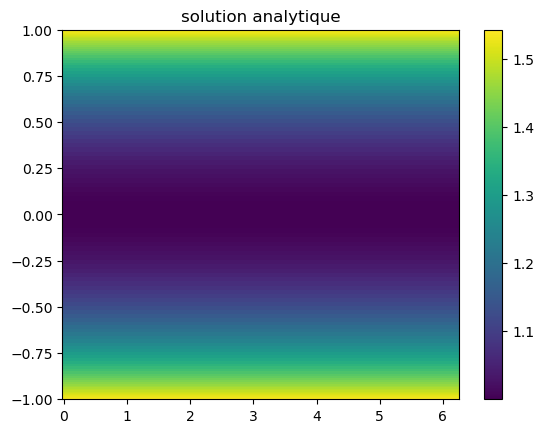

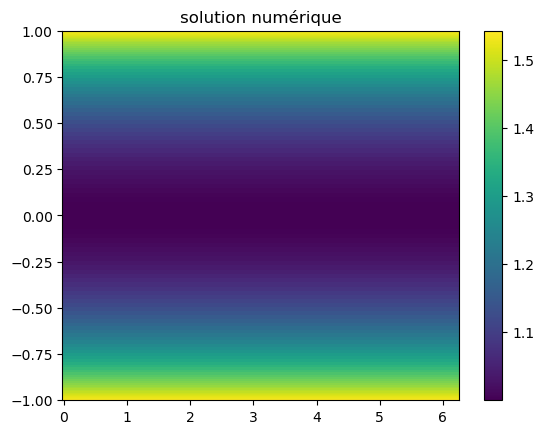

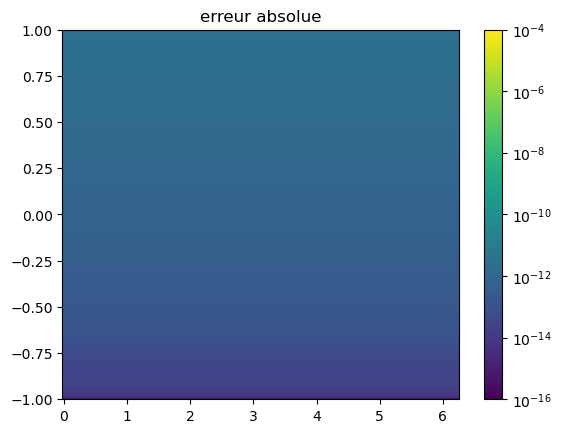

In [5]:
#cas 1D avec psi(x, y) = cosh(y), alpha^2 = 2, rhs = -cosh(y)
Nx= 128
Ny = 128
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2 = 2.*l**2

print(f'alpha^2 {alpha2}')

rhs = -np.cosh(l*Y)

bc_y1 = np.cosh(l) * np.ones(Nx)
bc_ym1 = bc_y1.copy()


psi_analytique = np.cosh(l*Y)

psi_num = Solve_Helmholtz(Nx,
                          Ny,
                          alpha2 = alpha2,
                          rhs = rhs,
                          CL_y_inf = bc_ym1,
                          CL_y_sup = bc_y1,
                          interval_x = (x_inf, x_sup),
                          interval_y = (y_inf, y_sup))

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num)
fig.colorbar(cf, ax=ax)

err = np.abs(psi_analytique - psi_num)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err, norm=colors.LogNorm(vmin=1.0e-16, vmax=1.0e-4))
fig.colorbar(cf, ax=ax)


Nx = 128
Ny = 128
X.shape (128, 128)
Y.shape (128, 128)
alpha^2 2.0


'\nerr_rhs = np.abs(err_rhs  -RHS_comp)\n\nfig  = plt.figure()\nax=plt.axes()\nax.set_title("erreur absolue")\ntry:\n    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=err_rhs.min(), vmax=err_rhs.max()))\nexcept ValueError:\n    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_rhs.max()))\nfig.colorbar(cf, ax=ax)\n'

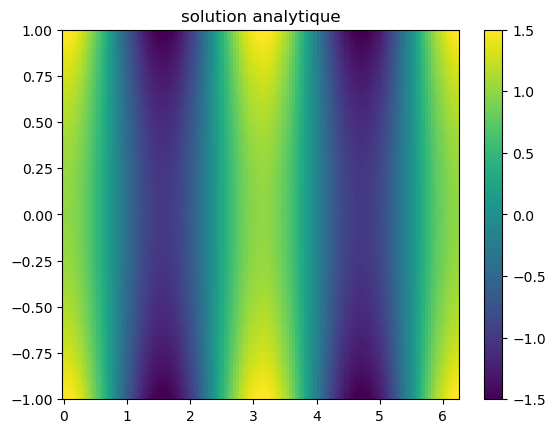

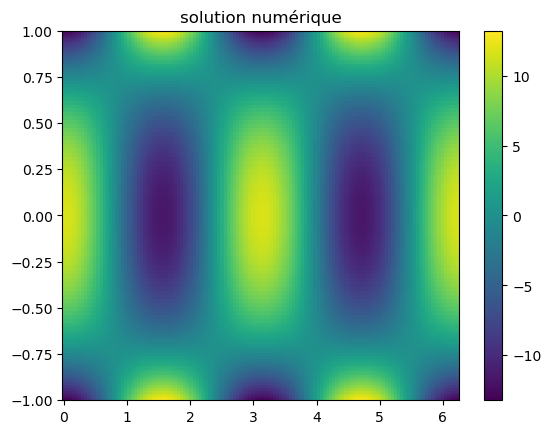

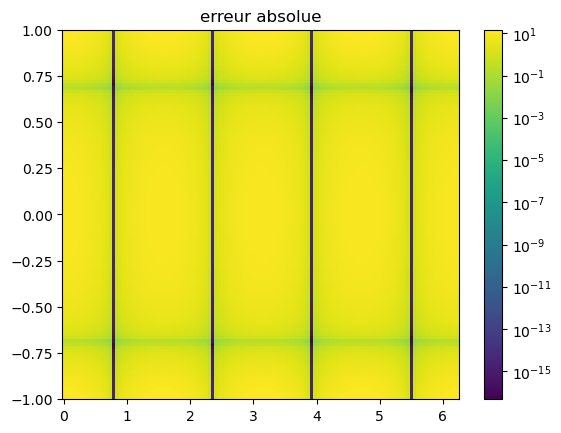

In [14]:
#Cas avec psi(x, y) = 

Nx= 128
Ny = 128
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2_2 = 3.0

print(f'alpha^2 {alpha2}')

bc_y1_2 = np.cos(k*x)*np.cosh(l)
bc_ym1_2 = np.cos(k*x)*np.cosh(l)

#bc_y1_2 = np.cos(k*x)*np.sinh(l)
#bc_ym1_2 = -np.cos(k*x)*np.sinh(l)



psi_analytique_2 = np.cos(k*X)*np.cosh(l*Y)
#psi_analytique_2 = np.cos(k*X)*np.sinh(l*Y)

rhs_2 = (l**2-k**2-alpha2_2)*np.cos(k*X)*np.cosh(l*Y)
#rhs_2 = -6.0*np.cos(k*X)*np.sinh(l*Y)
#rhs_2 = np.zeros((Nx, Ny))

psi_num_2 = Solve_Helmholtz(Nx,
                            Ny,
                            alpha2 = alpha2_2,
                            rhs = rhs_2,
                            CL_y_inf = bc_ym1_2,
                            CL_y_sup = bc_y1_2,
                            interval_x = (x_inf, x_sup),
                            interval_y = (y_inf, y_sup)
                           )
"""
RHS_comp = (Chebyshev.Cheb_derivative_2D(psi_analytique_2, order = 2, axis =0, a = x_inf, b = x_sup)+
            Chebyshev.Cheb_derivative_2D(psi_analytique_2, order = 2, axis =1, a = y_inf, b = y_sup) - alpha2_2 * psi_analytique_2)
"""
VMAX = max(psi_analytique_2.max(), psi_num_2.max())
VMIN = min(psi_analytique_2.min(), psi_num_2.min())

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique_2, vmin = -1.5, vmax = 1.5)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num_2, vmin = VMIN, vmax = VMAX)
fig.colorbar(cf, ax=ax)

err_2 = np.abs(psi_analytique_2 - psi_num_2)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
try:
    cf = ax.pcolormesh(X, Y, err_2, norm=colors.LogNorm(vmin=err_2.min(), vmax=err_2.max()))
except ValueError:
    cf = ax.pcolormesh(X, Y, err_2, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_2.max()))
fig.colorbar(cf, ax=ax)
"""
err_rhs = np.abs(err_rhs  -RHS_comp)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
try:
    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=err_rhs.min(), vmax=err_rhs.max()))
except ValueError:
    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_rhs.max()))
fig.colorbar(cf, ax=ax)
"""

Text(0, 0.5, '$\\psi(x, y_0)$')

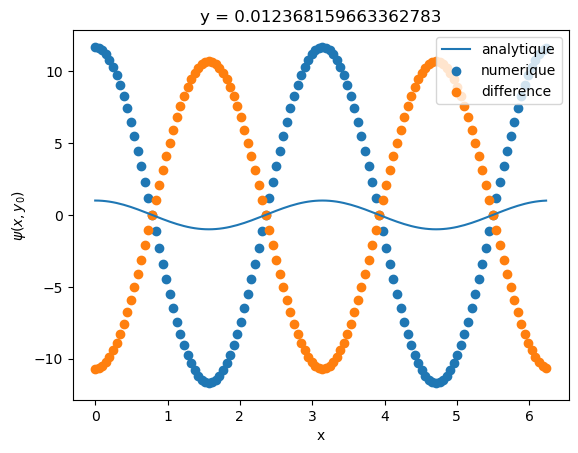

In [7]:
#cas en y = 0
y_0 = 0.0
y_index = np.abs(y - y_0).argmin()

y_sel = y[y_index]
psi_ana_y = psi_analytique_2[:, y_index]
psi_num_y = psi_num_2[:, y_index]

fig = plt.figure()
plt.title(f"y = {y_sel}")
plt.plot(x, psi_ana_y, label = 'analytique')
plt.scatter(x, psi_num_y, label = 'numerique')
plt.scatter(x, psi_ana_y - psi_num_y, label ='difference')
plt.legend()
plt.xlabel('x')
plt.ylabel(r"$\psi(x, y_0)$")


[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63. -64. -63. -62. -61. -60. -59.
 -58. -57. -56. -55. -54. -53. -52. -51. -50. -49. -48. -47. -46. -45.
 -44. -43. -42. -41. -40. -39. -38. -37. -36. -35. -34. -33. -32. -31.
 -30. -29. -28. -27. -26. -25. -24. -23. -22. -21. -20. -19. -18. -17.
 -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.
  -2.  -1.]
mode en kx = 2.0
mode en kx = -2.0


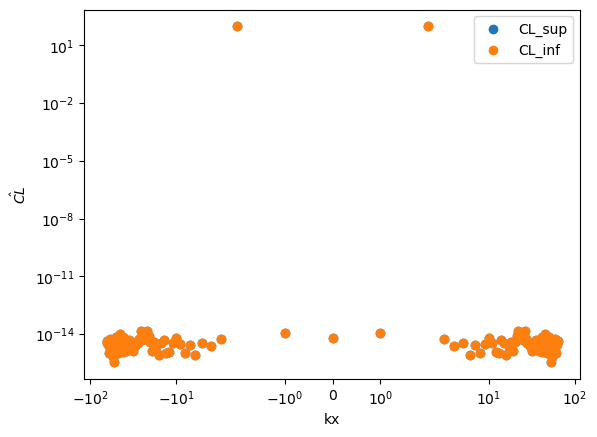

In [8]:
kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (x_sup - x_inf)/Nx)

print(kx)

CL_sup_hat = np.abs(scipy.fft.fft(bc_y1_2))
CL_inf_hat = np.abs(scipy.fft.fft(bc_ym1_2))
def sort_k(z_hat,K):
    new_z_hat = z_hat.copy()

    K_argsort = np.argsort(K)
    for i in range(0, z_hat.shape[0]):
        new_z_hat[i] = z_hat[K_argsort[i]]
    return new_z_hat

kx_sorted = np.sort(kx)
fig = plt.figure()
plt.scatter(kx_sorted, sort_k(CL_sup_hat, kx), label = r"CL_sup")
plt.scatter(kx_sorted, sort_k(CL_inf_hat, kx), label = r"CL_inf")

plt.xlabel("kx")
plt.ylabel(r"$\hat{CL}$")
plt.legend()
plt.xscale('symlog')
plt.yscale('log')


for i in range(0, kx.size) : 
    if CL_sup_hat[i] > 1.0e-10 : 
        print(f"mode en kx = {kx[i]}")

In [9]:
CL_inf_hat.min()

3.3601063255689654e-16

In [10]:
CL_sup_hat.min()

3.3601063255689654e-16

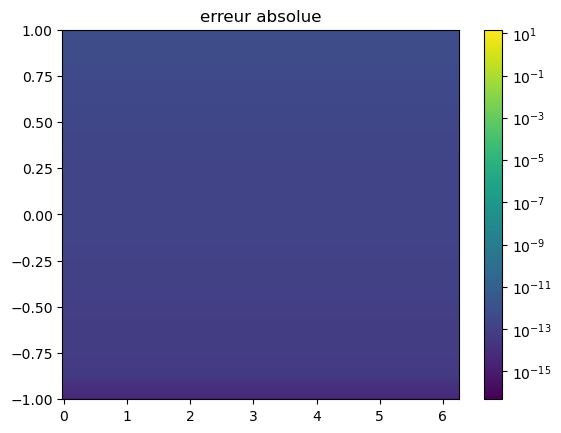

In [11]:
#cas psi(x, y = 1.0)
sol_ana = 1.0*np.ones((Nx, Ny))
psi_num_3 = Solve_Helmholtz(Nx,
                            Ny,
                            alpha2 = 3.0,
                            rhs = -3.0,
                            CL_y_inf = 1.0,
                            CL_y_sup = 1.0,
                            interval_x = (x_inf, x_sup),
                            interval_y = (y_inf, y_sup)
                           )
fig = plt.figure()
err_3 = np.abs(sol_ana-psi_num_3)
ax=plt.axes()
ax.set_title("erreur absolue")
try:
    cf = ax.pcolormesh(X, Y, err_3, norm=colors.LogNorm(vmin=err_2.min(), vmax=err_2.max()))
except ValueError:
    cf = ax.pcolormesh(X, Y, err_3, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_2.max()))
fig.colorbar(cf, ax=ax)